In [23]:
import tqdm
import pandas
import joblib
import sklearn.compose
import sklearn.preprocessing
import sklearn.model_selection
import matplotlib.pyplot as plt

from lazyfca import LazyFCA

from utils import estimate_quality

In [24]:
data = pandas.read_csv("churn.csv")
data = data.drop(columns = ['customerID'])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

X = data.drop(columns = ["Churn"])
# y = data["Churn"].to_numpy()
y = (data["Churn"] == "Yes").to_numpy()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))
ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool'), categorical)
    ]
)
X_train = pandas.DataFrame(ct.fit_transform(X_train), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(ct.transform(X_test), columns = ct.get_feature_names_out())

categorical = [ feature for feature in ct.get_feature_names_out() if feature.startswith("categorical__") ]
X_train[categorical] = X_train[categorical].astype(bool)
X_test[categorical] = X_test[categorical].astype(bool)

y_train = pandas.Series(y_train)
y_test = pandas.Series(y_test)

In [25]:
classifier = LazyFCA(
    pos_params=LazyFCA.Params(
        supporters_covered=5,
        supporter_opposer_ratio=2.75,
        matthews_correlation=0.05
    ),
    neg_params=LazyFCA.Params(
        supporters_covered=10,
        supporter_opposer_ratio=0.25,
        lift=0.05,
        matthews_correlation=0.05
    ),
    pos_weight=1.0
)
classifier.fit(X_train, y_train)

In [26]:
y_pred = classifier.predict(X_test)

100%|██████████| 704/704 [01:30<00:00,  7.77it/s]


In [27]:
estimate_quality(y_pred, y_test)

[433  84   0   0]


{'total': {'Accuracy': 0.7769886363636364,
  'Precision': 0.5757575757575758,
  'Recall': 0.6096256684491979,
  'AUC-ROC': 0.7961242875908936,
  'F1-score': 0.5922077922077922,
  'True Positive': np.int64(114),
  'True Negative': np.int64(433),
  'False Positive': np.int64(84),
  'False Negative': np.int64(73),
  'True Negative Rate (Specificity)': np.float64(0.8375241779497099),
  'Negative Predictive Value': np.float64(0.8557312252964426),
  'False Positive Rate': np.float64(0.16247582205029013),
  'False Discovery Rate': np.float64(0.42424242424242425),
  'Balanced precision proxy': np.float64(0.44714984639890776),
  "Youden's J": np.float64(0.44714984639890776),
  'Matthews correlation': 0.43924953171762543},
 'positive': {'Support': np.float64(0.6096256684491979),
  'Contamination': np.float64(0.0),
  'Confidence': np.float64(1.0),
  'Lift': np.float64(3.764705882352941),
  'WRAcc': np.float64(0.11891867897727272),
  'Balanced precision proxy': np.float64(0.6096256684491979),
  'M

In [28]:
classifier.explain(X_test.iloc[52]).display()

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
0,0; 0; 0; 0; 1; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0...,POSITIVE,1682,4646,23,7,3.285714,0.013674,0.001507,0.766667,2.884344,0.002375,0.012168,0.012168,0.078252,0.060199,0.002824,3.133333,1636.325053,-211.432701
1,0; 0; 1; 0; 1; 0; 0; 0; 0; 1; 0; 0; 0; 0; 1; 1...,POSITIVE,1682,4646,14,4,3.500000,0.008323,0.000861,0.777778,2.926146,0.001456,0.007462,0.007462,0.061899,0.040719,0.001652,3.222222,1654.119972,-142.079637
2,0; 0; 1; 0; 1; 0; 0; 0; 0; 1; 0; 0; 1; 0; 1; 1...,POSITIVE,1682,4646,36,11,3.272727,0.021403,0.002368,0.765957,2.881676,0.003715,0.019035,0.019035,0.097938,0.084643,0.004272,3.173913,1610.796555,-298.757768
3,0; 0; 1; 0; 0; 0; 0; 0; 0; 1; 0; 0; 1; 0; 1; 1...,POSITIVE,1682,4646,86,31,2.774194,0.051130,0.006672,0.735043,2.765369,0.008676,0.044457,0.044457,0.145788,0.158678,0.010686,2.746032,1514.603991,-573.216039
4,0; 0; 1; 0; 0; 0; 0; 0; 0; 1; 0; 0; 1; 0; 1; 1...,POSITIVE,1682,4646,39,13,3.000000,0.023187,0.002798,0.750000,2.821641,0.003979,0.020389,0.020389,0.099769,0.090073,0.005051,2.925926,1604.940656,-319.569412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,0; 0; 1; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1...,NEGATIVE,4646,1682,188,31,6.064516,0.040465,0.018430,0.858447,1.169233,0.004300,0.022034,0.022034,0.053254,0.148043,0.034884,5.984127,4278.178748,-1267.377415
142,0; 0; 1; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1...,NEGATIVE,4646,1682,154,13,11.846154,0.033147,0.007729,0.922156,1.256005,0.004960,0.025418,0.025418,0.070050,0.120624,0.014299,11.444444,4343.205082,-1075.196532
143,0; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1...,NEGATIVE,4646,1682,80,5,16.000000,0.017219,0.002973,0.941176,1.281912,0.002780,0.014246,0.014246,0.054671,0.072908,0.005640,14.636364,4487.392392,-659.862767
144,0; 0; 1; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1...,NEGATIVE,4646,1682,286,60,4.766667,0.061558,0.035672,0.826590,1.125841,0.005052,0.025887,0.025887,0.050300,0.206638,0.066282,4.735537,4093.745991,-1712.438276


In [29]:
def explain(item):
    return classifier.explain(item).display()

scores = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(explain)(item)
    for _, item in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
)
scores = pandas.concat(list(scores), axis = 0).drop_duplicates()
scores

100%|██████████| 704/704 [01:37<00:00,  7.23it/s]


,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
0,1; 0; 1; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 1; 0; 0...,POSITIVE,1682,4646,69,25,2.760000,0.041023,0.005381,0.734043,2.761606,0.006956,0.035642,0.035642,0.130156,0.136378,0.009050,2.725490,1546.965083,-490.586496
1,1; 0; 1; 0; 1; 0; 0; 1; 0; 0; 0; 1; 0; 1; 0; 1...,POSITIVE,1682,4646,54,18,3.000000,0.032105,0.003874,0.750000,2.821641,0.005509,0.028230,0.028230,0.117586,0.114267,0.006703,2.945946,1575.803388,-407.315690
2,1; 0; 1; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 1; 0; 1...,POSITIVE,1682,4646,76,27,2.814815,0.045184,0.005811,0.737864,2.775983,0.007684,0.039373,0.039373,0.137455,0.145731,0.009548,2.781818,1533.590916,-524.587622
3,1; 0; 1; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 1; 0; 0...,POSITIVE,1682,4646,10,2,5.000000,0.005945,0.000430,0.833333,3.135157,0.001076,0.005515,0.005515,0.055998,0.030901,0.000825,4.200000,1662.060314,-106.502214
4,1; 0; 1; 0; 1; 0; 0; 1; 0; 0; 0; 1; 0; 1; 0; 1...,POSITIVE,1682,4646,49,17,2.882353,0.029132,0.003659,0.742424,2.793139,0.004971,0.025473,0.025473,0.110765,0.106661,0.006456,2.828571,1585.489671,-380.457737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,223,42,5.309524,0.047998,0.024970,0.841509,1.146163,0.004494,0.023028,0.023028,0.050786,0.170407,0.047013,5.258824,4211.752368,-1437.261612
41,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,183,27,6.777778,0.039389,0.016052,0.871429,1.186913,0.004554,0.023336,0.023336,0.057554,0.143317,0.030295,6.672727,4287.641549,-1237.309178
42,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,282,40,7.050000,0.060697,0.023781,0.875776,1.192835,0.007204,0.036916,0.036916,0.074208,0.193561,0.043313,6.975309,4100.067908,-1659.287251
43,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,307,42,7.309524,0.066078,0.024970,0.879656,1.198120,0.008022,0.041108,0.041108,0.079552,0.204185,0.044951,7.235294,4053.334804,-1751.127706


In [30]:
scores.sort_values(by='Balanced precision proxy', ascending=False)

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
567,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,2608,415,6.284337,0.561343,0.246730,0.862719,1.175051,0.061397,0.314613,0.314613,0.278243,0.537558,0.117478,6.277978,996.375765,-3729.800744
1094,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,2425,353,6.869688,0.521954,0.209869,0.872930,1.188959,0.060904,0.312085,0.312085,0.277808,0.525482,0.103257,6.861386,1135.823174,-3779.459209
470,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,2570,409,6.283619,0.553164,0.243163,0.862706,1.175033,0.060497,0.310001,0.310001,0.274361,0.538389,0.121207,6.277167,1027.085138,-3752.731818
104,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,2559,412,6.211165,0.550796,0.244946,0.861326,1.173154,0.059687,0.305850,0.305850,0.270728,0.540634,0.126518,6.204848,1038.405901,-3765.979734
27,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,2663,452,5.891593,0.573181,0.268728,0.854896,1.164395,0.059415,0.304454,0.304454,0.269023,0.547872,0.136704,5.886188,967.846541,-3734.107727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 1...,POSITIVE,1682,4646,6,0,inf,0.003567,0.000000,1.000000,3.762188,0.000696,0.003567,0.003567,0.051201,0.020105,-0.000013,13.000000,1670.021403,-67.631752
7,0; 0; 0; 0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,6,0,inf,0.003567,0.000000,1.000000,3.762188,0.000696,0.003567,0.003567,0.051201,0.020105,-0.000013,13.000000,1670.021403,-67.631752
26,1; 0; 1; 0; 1; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 1...,POSITIVE,1682,4646,6,0,inf,0.003567,0.000000,1.000000,3.762188,0.000696,0.003567,0.003567,0.051201,0.020105,-0.000013,13.000000,1670.021403,-67.631752
2,0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 1; 0; 1; 1...,POSITIVE,1682,4646,6,0,inf,0.003567,0.000000,1.000000,3.762188,0.000696,0.003567,0.003567,0.051201,0.020105,-0.000013,13.000000,1670.021403,-67.631752


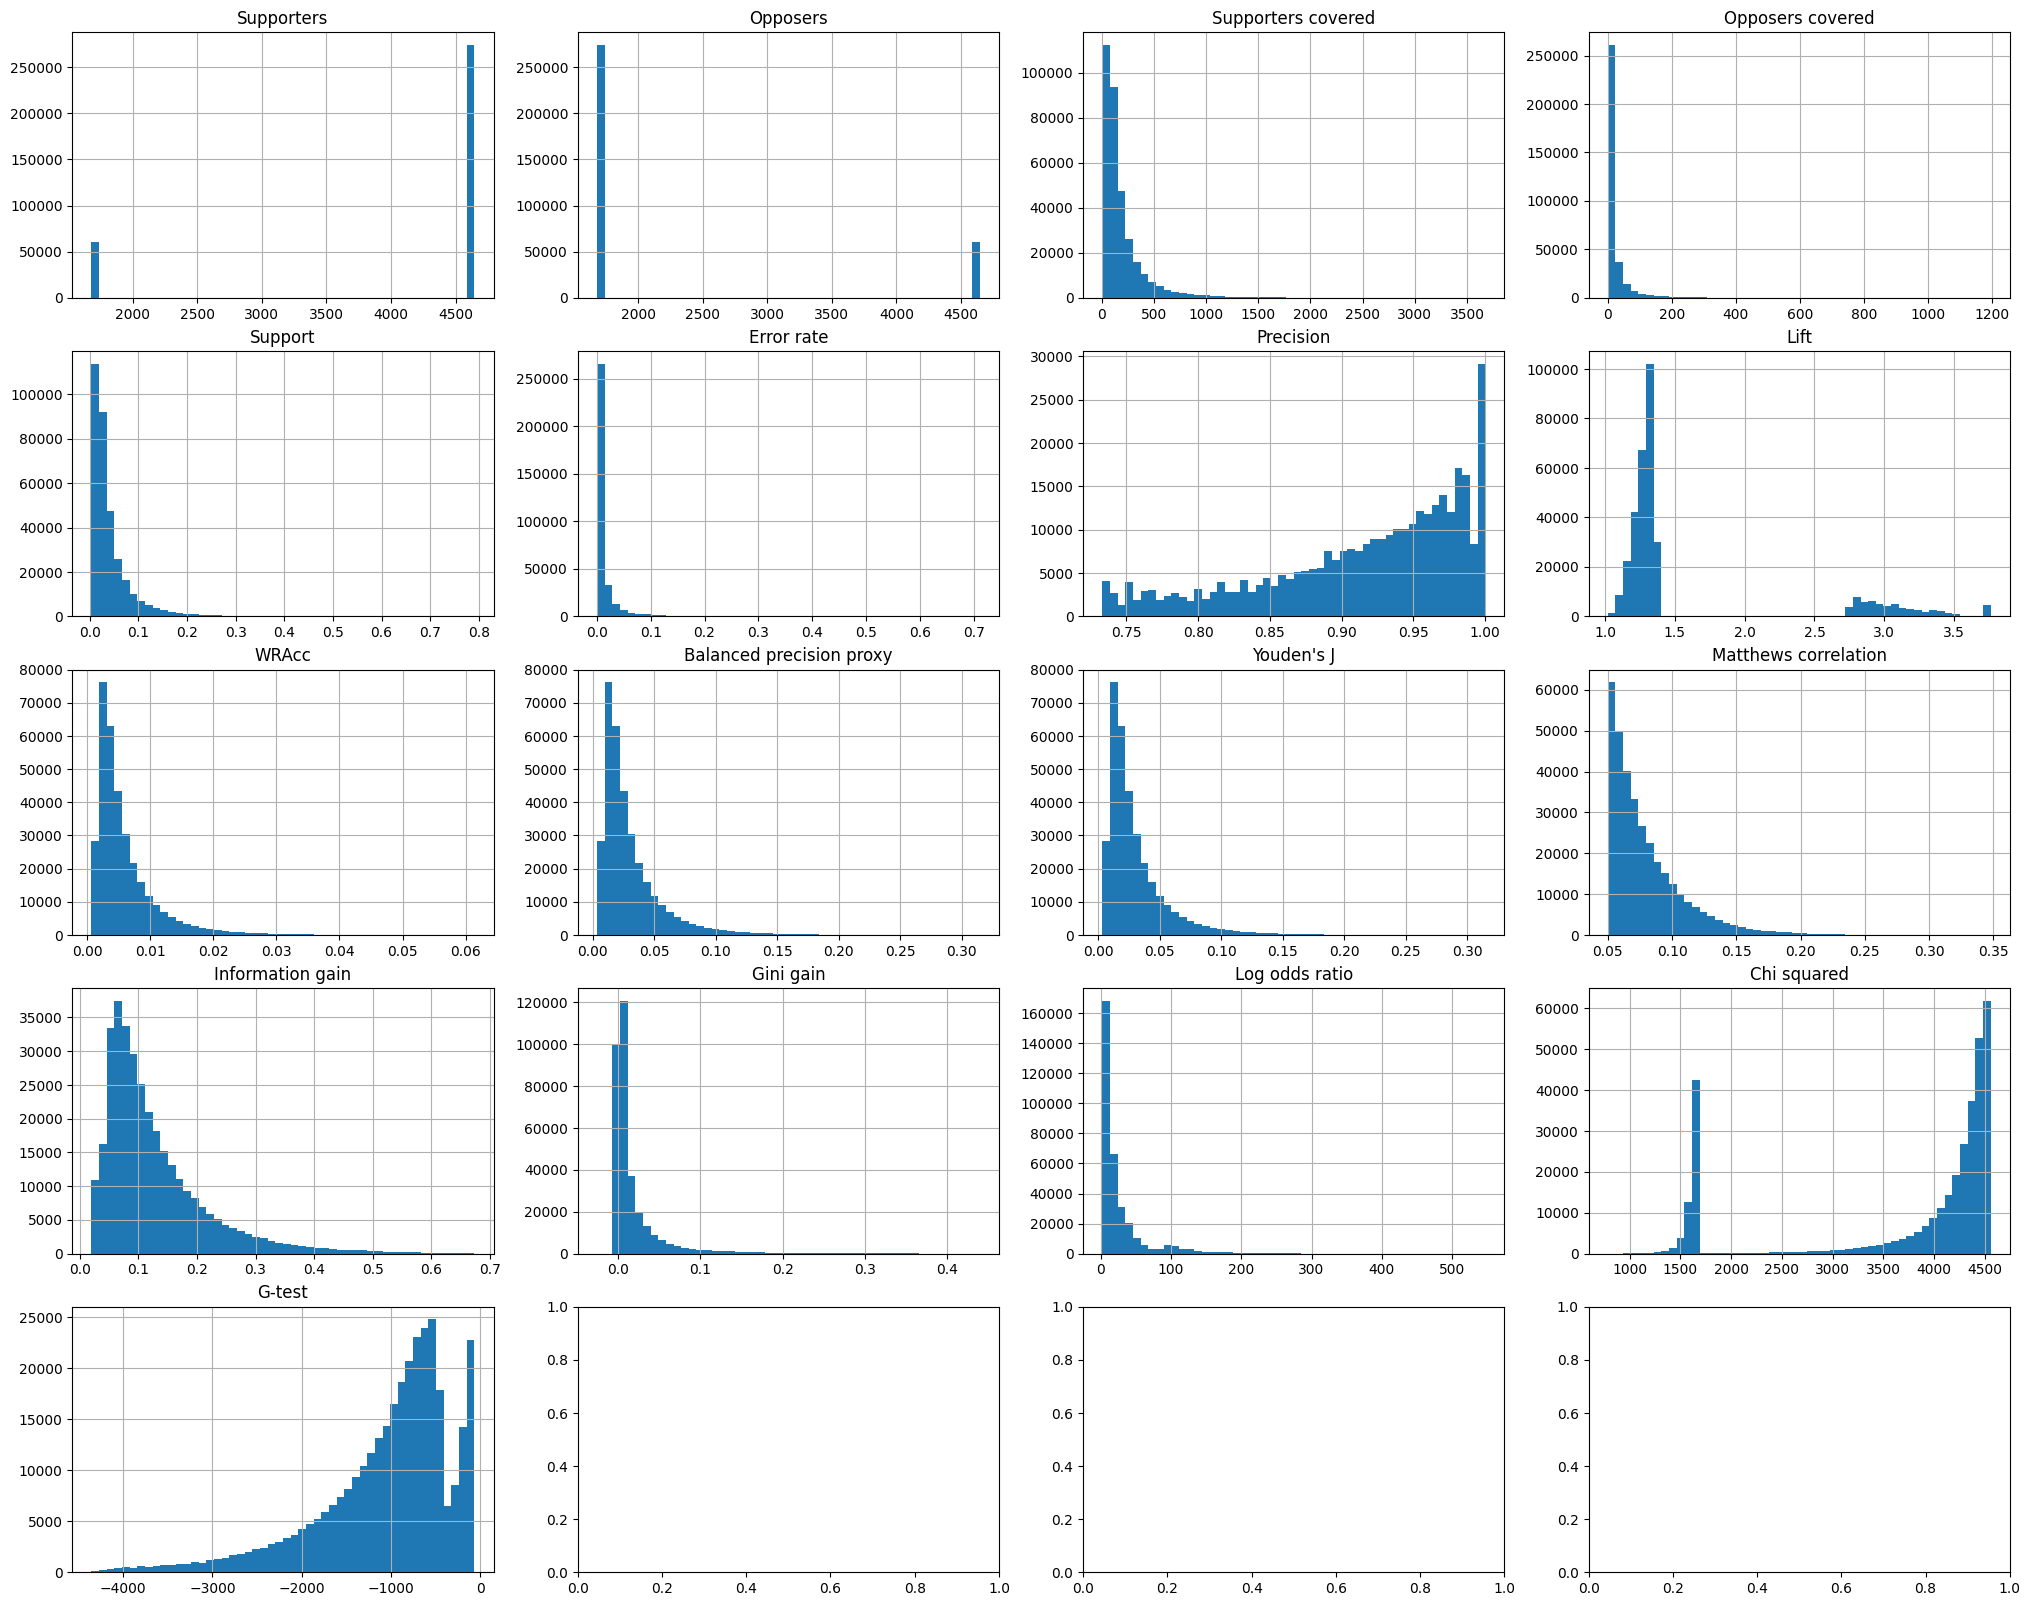

In [31]:
COLUMNS = [
    'Supporters', 'Opposers', 'Supporters covered', 'Opposers covered',
    'Support', 'Error rate', 'Precision', 'Lift',
    'WRAcc', 'Balanced precision proxy', 'Youden\'s J', 'Matthews correlation',
    'Information gain',	'Gini gain', 'Log odds ratio',	'Chi squared',
    'G-test'
]
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    scores[column].hist(ax = ax, bins = 50)

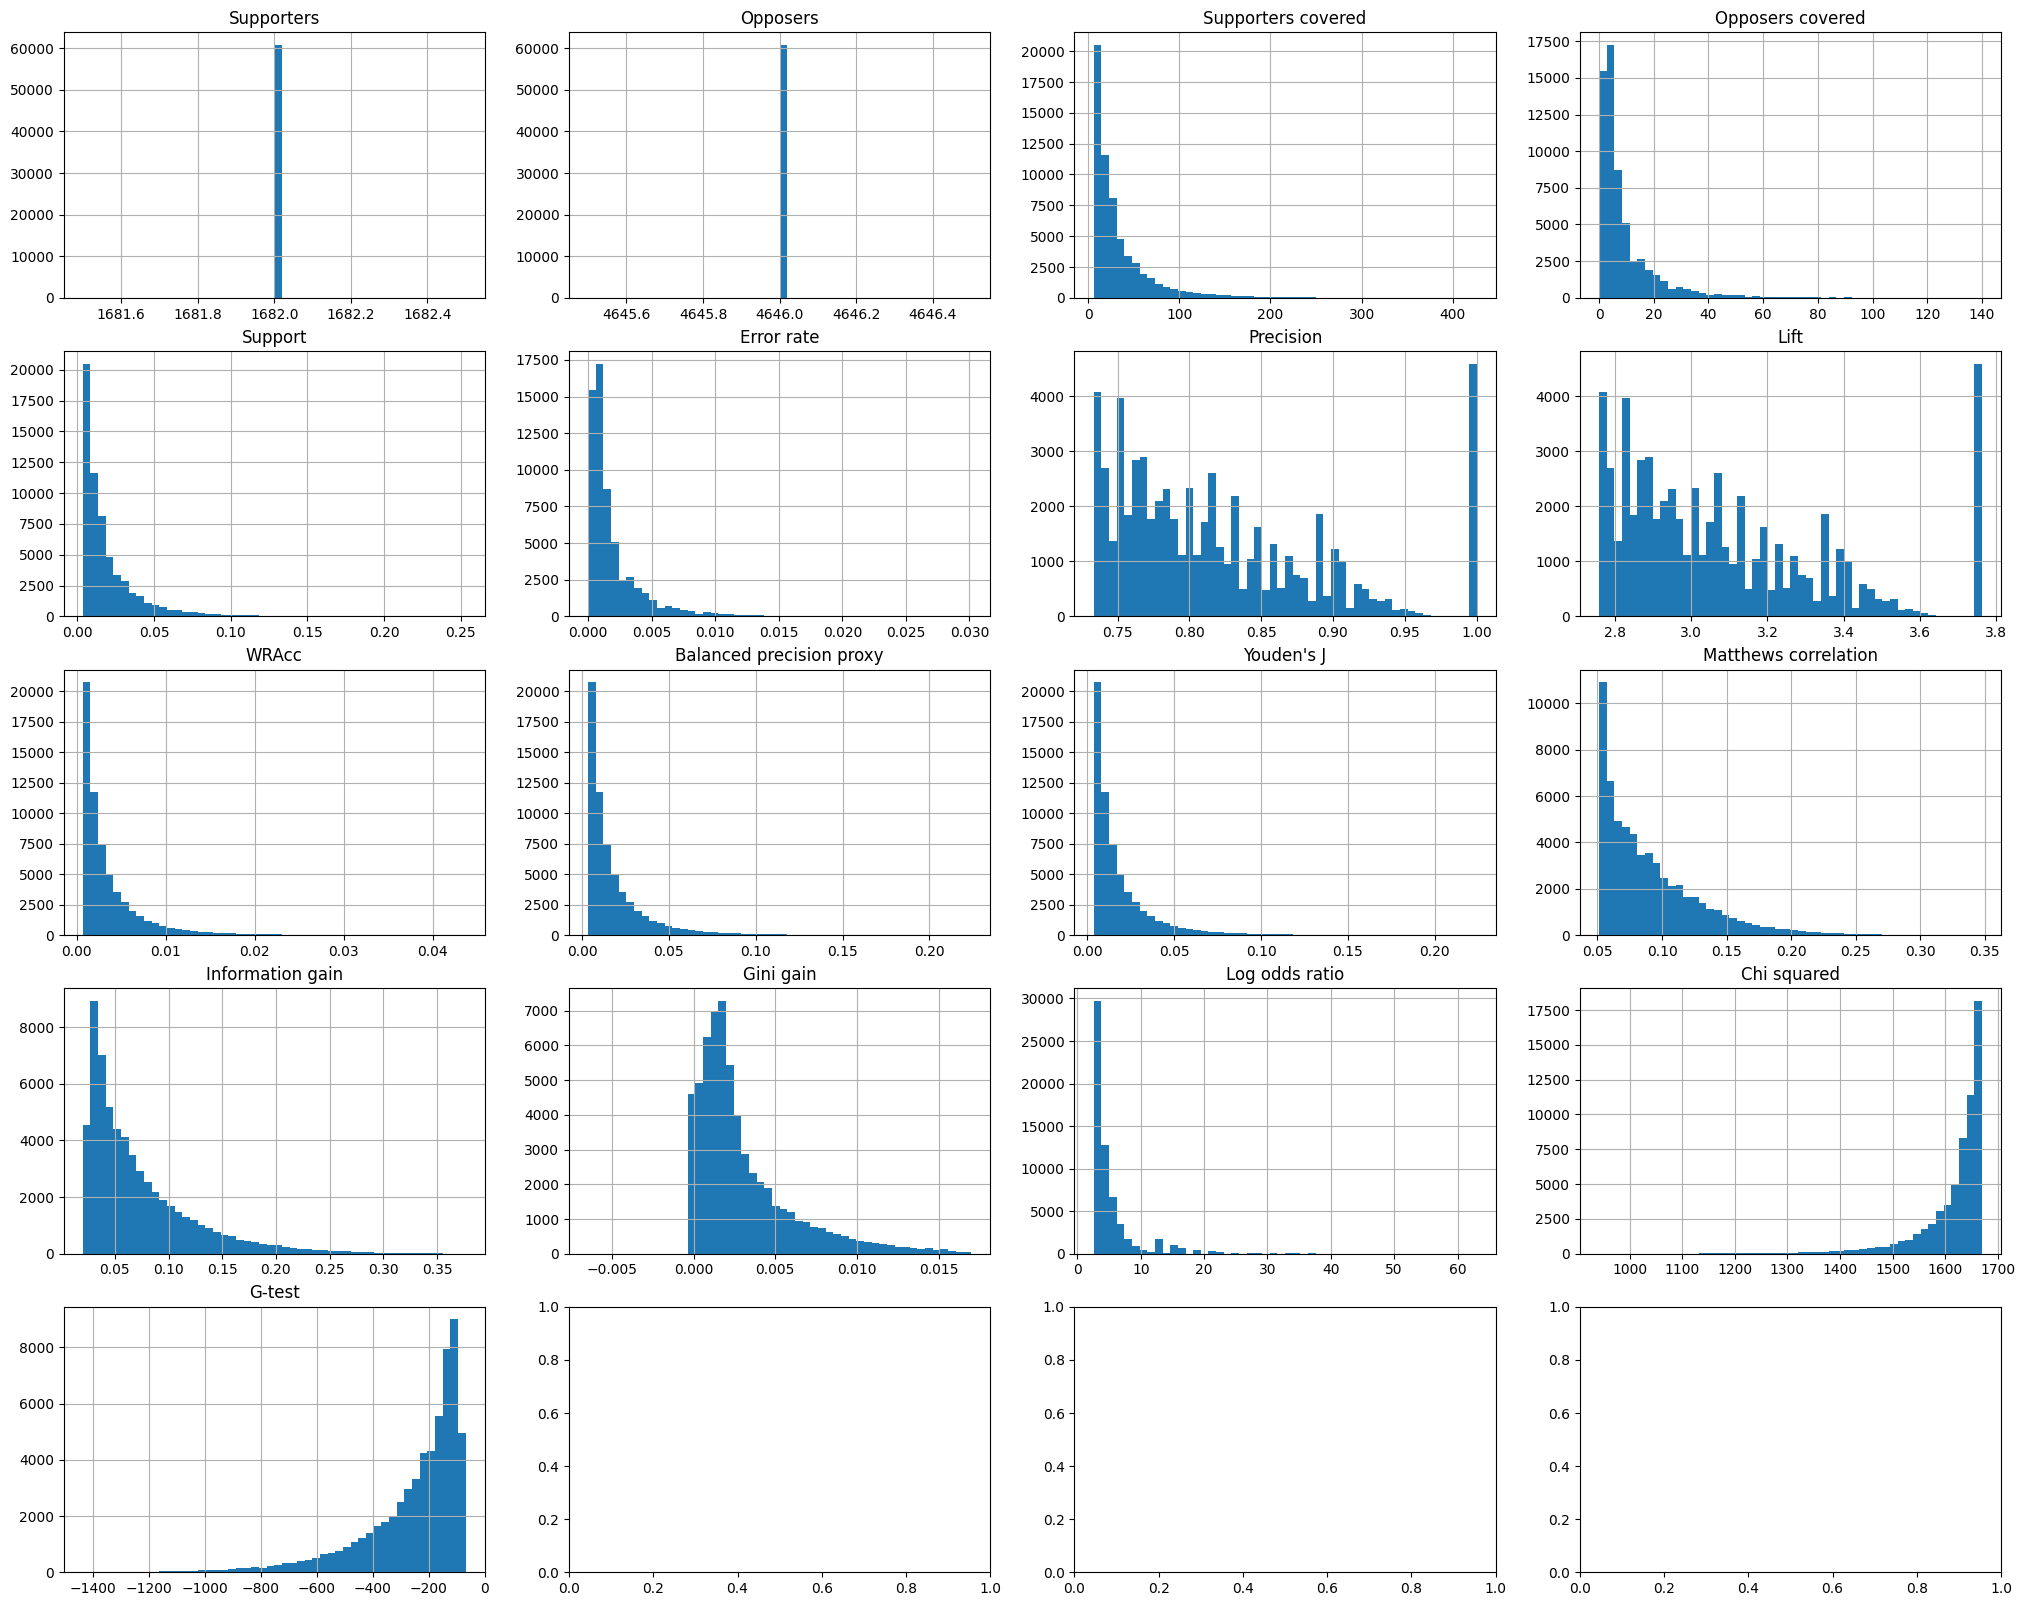

In [32]:
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    scores[scores["Type"] == "POSITIVE"][column].hist(ax = ax, bins = 50)

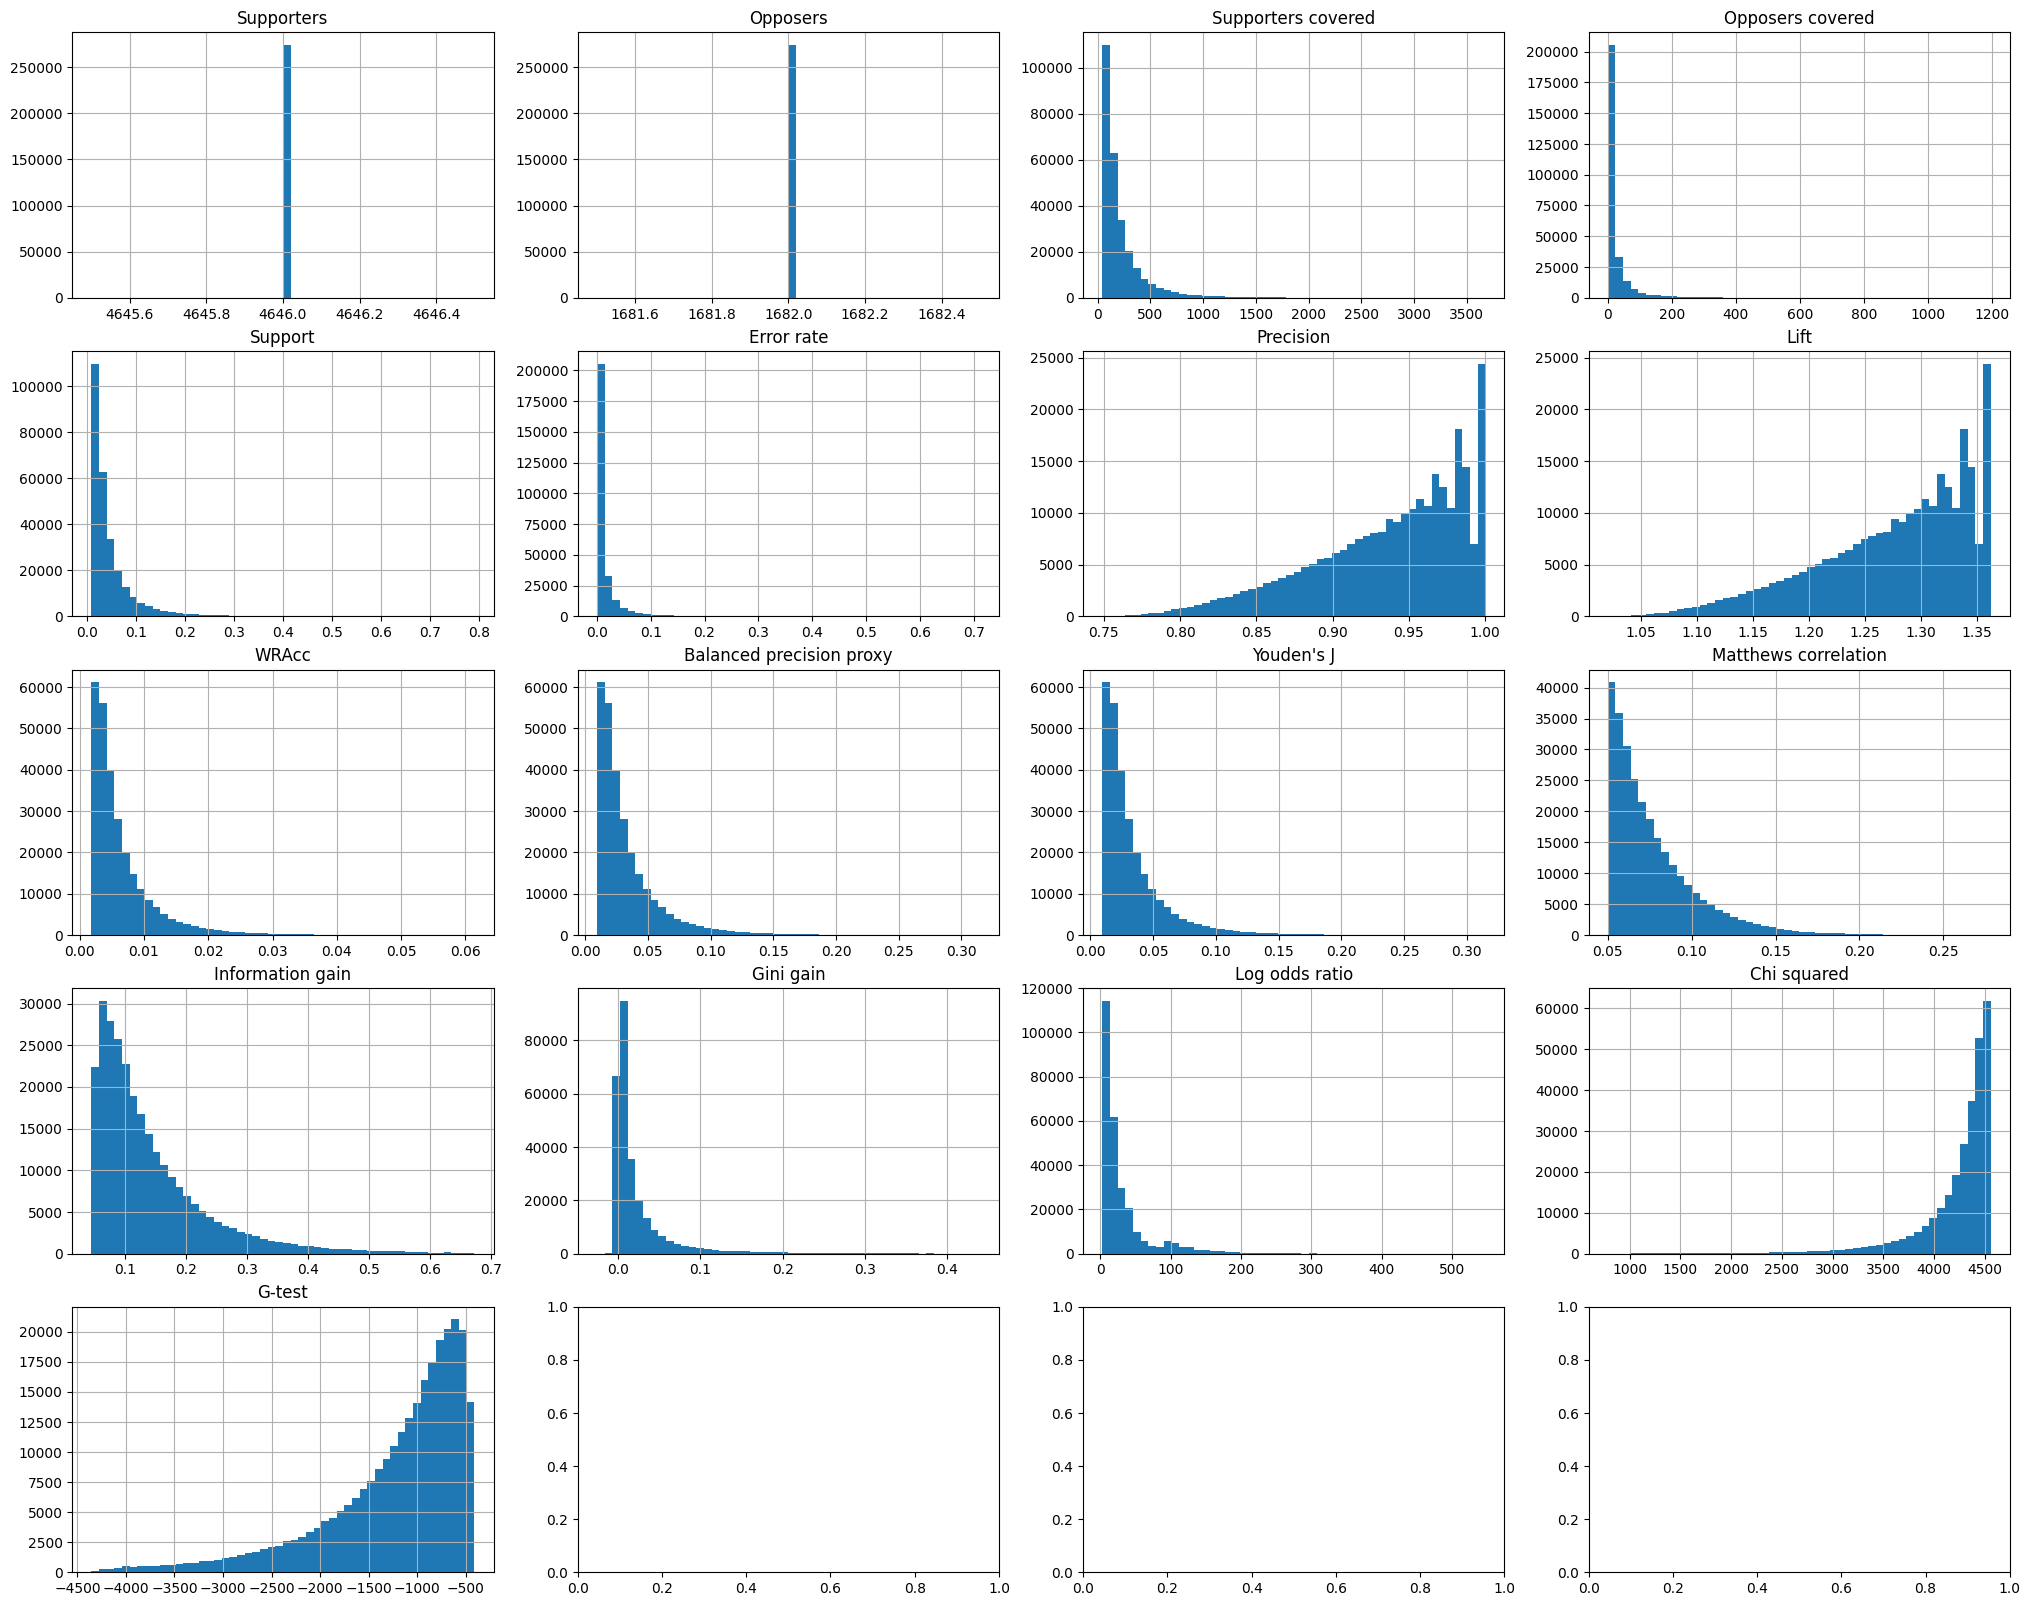

In [33]:
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    scores[scores["Type"] == "NEGATIVE"][column].hist(ax = ax, bins = 50)

## 5. Stability/robustness

I slightly change one object and see the results

In [34]:
idx = 502
example = X_test.iloc[idx]
example.to_frame().T

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes,categorical__TechSupport_No,categorical__TechSupport_Yes,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,categorical__PaperlessBilling_No,...,categorical__Dependents_Yes,categorical__DeviceProtection_No,categorical__DeviceProtection_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year
502,72.0,19.55,1463.45,True,False,True,False,True,False,True,...,True,True,False,True,False,False,False,False,False,True


In [35]:
y_pred = classifier.predict(example.to_frame().T)
y_pred

100%|██████████| 1/1 [00:00<00:00, 753.15it/s]


array([[1., 0.]])

In [36]:
y_test.iloc[idx]

np.False_

In [37]:
classifier.explain(example).display()

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
0,1; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 1; 0; 1; 0; 1...,NEGATIVE,4646,1682,317,14,22.642857,0.068231,0.008323,0.957704,1.304423,0.011691,0.059907,0.059907,0.118864,0.191479,0.011922,21.896552,4033.745671,-1730.084476
1,1; 0; 1; 0; 1; 0; 0; 0; 0; 0; 1; 1; 0; 1; 0; 1...,NEGATIVE,4646,1682,67,4,16.750000,0.014421,0.002378,0.943662,1.285298,0.002350,0.012043,0.012043,0.050509,0.063507,0.004543,15.000000,4512.975720,-576.025765
2,1; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,78,5,15.600000,0.016789,0.002973,0.939759,1.279982,0.002696,0.013816,0.013816,0.053645,0.071584,0.005655,14.272727,4491.324377,-647.565404
3,1; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,169,7,24.142857,0.036375,0.004162,0.960227,1.307860,0.006287,0.032214,0.032214,0.086542,0.124696,0.006983,22.600000,4314.176571,-1134.056589
4,1; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0...,NEGATIVE,4646,1682,196,13,15.076923,0.042187,0.007729,0.937799,1.277312,0.006725,0.034458,0.034458,0.085178,0.141248,0.013618,14.555556,4262.369094,-1266.832988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1923,1; 0; 1; 0; 1; 0; 1; 0; 0; 0; 1; 1; 0; 0; 0; 1...,NEGATIVE,4646,1682,69,1,69.000000,0.014851,0.000595,0.985714,1.342574,0.002782,0.014257,0.014257,0.060216,0.063114,0.000968,46.333333,4509.025347,-582.931852
1924,1; 0; 1; 0; 1; 0; 1; 0; 0; 0; 1; 1; 0; 1; 0; 1...,NEGATIVE,4646,1682,85,1,85.000000,0.018295,0.000595,0.988372,1.346194,0.003454,0.017701,0.017701,0.067536,0.073796,0.000854,57.000000,4477.555696,-682.188217
1925,1; 0; 1; 0; 1; 0; 1; 0; 0; 0; 0; 1; 0; 1; 0; 1...,NEGATIVE,4646,1682,244,26,9.384615,0.052518,0.015458,0.903704,1.230873,0.007232,0.037061,0.037061,0.081006,0.170088,0.027918,9.226415,4171.216367,-1489.533730
1926,1; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0...,NEGATIVE,4646,1682,74,1,74.000000,0.015928,0.000595,0.986667,1.343871,0.002992,0.015333,0.015333,0.062591,0.066530,0.000935,49.666667,4499.179243,-614.674535


Let's mess with some features

In [38]:
example_mess = example.copy().to_frame().T
example_mess['numeric__tenure'] = 10
example_mess['numeric__MonthlyCharges'] = 100
example_mess['numeric__TotalCharges'] = 500
example_mess

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes,categorical__TechSupport_No,categorical__TechSupport_Yes,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,categorical__PaperlessBilling_No,...,categorical__Dependents_Yes,categorical__DeviceProtection_No,categorical__DeviceProtection_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year
502,10,100,500,True,False,True,False,True,False,True,...,True,True,False,True,False,False,False,False,False,True


In [39]:
y_pred = classifier.predict(example_mess)
y_pred

100%|██████████| 1/1 [00:00<00:00, 618.08it/s]


array([[0.59574468, 0.40425532]])

As we can see classifier less sure about negative class but still predict as negative despite I changed all 3 main features